
# Projeto ETL Loja Brasil
## Estatística descritiva, respostas de negócio e gráficos

Neste notebook, vamos utilizar os dados já carregados na **camada Gold** do Data Warehouse para responder perguntas simples de negócio.

### Objetivos

- Ler as tabelas da Gold com Pandas e SQLAlchemy;
- Conhecer os dados com estatística descritiva;
- Responder perguntas de negócio;
- Criar gráficos simples;
- Interpretar os resultados.

> **Importante:** este notebook não executa o ETL novamente. Ele parte do princípio de que as tabelas da Gold já foram criadas pelo `run_etl.py`.



## 1. Preparação

Vamos importar as bibliotecas e utilizar a conexão com o Data Warehouse criada no arquivo `src/config.py`.


In [1]:

import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Permite importar os scripts da pasta src
sys.path.append(str(Path.cwd() / "src"))

from config import engine_dw

pd.set_option("display.max_columns", None)



## 2. Carregando os dados da Gold

A Gold contém dados preparados para análise:

- `gold.fato_vendas`: registros detalhados de vendas;
- `gold.dim_municipios`: informações geográficas dos municípios;
- `gold.metas_vendas`: metas comerciais;
- `gold.fato_metas_mensais`: vendas realizadas, metas e percentual de atingimento.


In [2]:

df_vendas = pd.read_sql(
    "SELECT * FROM gold.fato_vendas",
    engine_dw
)

df_municipios = pd.read_sql(
    "SELECT * FROM gold.dim_municipios",
    engine_dw
)

df_metas = pd.read_sql(
    "SELECT * FROM gold.metas_vendas",
    engine_dw
)

df_metas_mensais = pd.read_sql(
    "SELECT * FROM gold.fato_metas_mensais",
    engine_dw
)

print("Vendas:", df_vendas.shape)
print("Municípios:", df_municipios.shape)
print("Metas:", df_metas.shape)
print("Resumo mensal:", df_metas_mensais.shape)


Vendas: (153, 15)
Municípios: (295, 8)
Metas: (12, 4)
Resumo mensal: (11, 7)


## 3. Conhecendo a tabela de vendas

In [3]:

display(df_vendas.head())
df_vendas.info()


,id_pedido,data_pedido,id_cliente,cliente,cidade,estado,id_ibge,id_produto,produto,categoria,marca,quantidade,preco_unitario,desconto,valor_item
0,1,2025-02-10,8,Henrique Martins,Jaraguá do Sul,SC,4208906,6,Calça Mom Feminina,Calças,Urban,2,159.9,0.0,319.80
1,1,2025-02-10,8,Henrique Martins,Jaraguá do Sul,SC,4208906,13,Cinto de Couro,Acessórios,Serra Sul,3,79.9,5.0,227.72
2,1,2025-02-10,8,Henrique Martins,Jaraguá do Sul,SC,4208906,2,Camiseta Polo Masculina,Camisetas,Estilo Brasil,4,89.9,10.0,323.64
3,2,2025-02-19,15,Otávio Ribeiro,Chapecó,SC,4204202,11,Tênis Casual Branco,Calçados,Urban,3,199.9,5.0,569.72
4,2,2025-02-19,15,Otávio Ribeiro,Chapecó,SC,4204202,18,Cachecol Tricot,Acessórios,Viva Moda,4,54.9,10.0,197.64


<class 'pandas.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id_pedido       153 non-null    int64         
 1   data_pedido     153 non-null    datetime64[us]
 2   id_cliente      153 non-null    int64         
 3   cliente         153 non-null    str           
 4   cidade          153 non-null    str           
 5   estado          153 non-null    str           
 6   id_ibge         153 non-null    int64         
 7   id_produto      153 non-null    int64         
 8   produto         153 non-null    str           
 9   categoria       153 non-null    str           
 10  marca           153 non-null    str           
 11  quantidade      153 non-null    int64         
 12  preco_unitario  153 non-null    float64       
 13  desconto        153 non-null    float64       
 14  valor_item      153 non-null    float64       
dtypes: datetime64[us]


## 4. Estatística descritiva

A estatística descritiva ajuda a entender os dados antes de tomar decisões.

Vamos observar:

- quantidade de registros;
- quantidade total vendida;
- valor mínimo, médio e máximo dos itens;
- distribuição dos descontos.


In [4]:

df_vendas[["quantidade", "preco_unitario", "desconto", "valor_item"]].describe()


,quantidade,preco_unitario,desconto,valor_item
count,153.000000,153.000000,153.000000,153.000000
mean,2.496732,133.233333,3.725490,314.538824
std,1.118764,68.395618,4.156851,215.098757
min,1.000000,29.900000,0.000000,29.900000
25%,2.000000,69.900000,0.000000,170.710000
50%,2.000000,139.900000,0.000000,251.640000
75%,3.000000,189.900000,5.000000,467.640000
max,4.000000,279.900000,10.000000,1007.640000


In [5]:

resumo_geral = pd.DataFrame({
    "indicador": [
        "Quantidade de pedidos",
        "Quantidade de itens vendidos",
        "Faturamento total",
        "Ticket médio por item"
    ],
    "valor": [
        df_vendas["id_pedido"].nunique(),
        df_vendas["quantidade"].sum(),
        df_vendas["valor_item"].sum(),
        df_vendas["valor_item"].mean()
    ]
})

resumo_geral


,indicador,valor
0,Quantidade de pedidos,51.000000
1,Quantidade de itens vendidos,382.000000
2,Faturamento total,48124.440000
3,Ticket médio por item,314.538824



## 5. Pergunta de negócio 1
### Quais categorias geram mais faturamento?

Essa análise pode ajudar a empresa a identificar quais categorias possuem maior participação nas vendas.


In [6]:

vendas_categoria = (
    df_vendas
    .groupby("categoria", as_index=False)["valor_item"]
    .sum()
    .sort_values("valor_item", ascending=False)
)

vendas_categoria


,categoria,valor_item
2,Calças,9931.38
0,Acessórios,9806.81
1,Calçados,9072.10
4,Jaquetas,7510.90
5,Vestidos,7335.54
3,Camisetas,4467.71


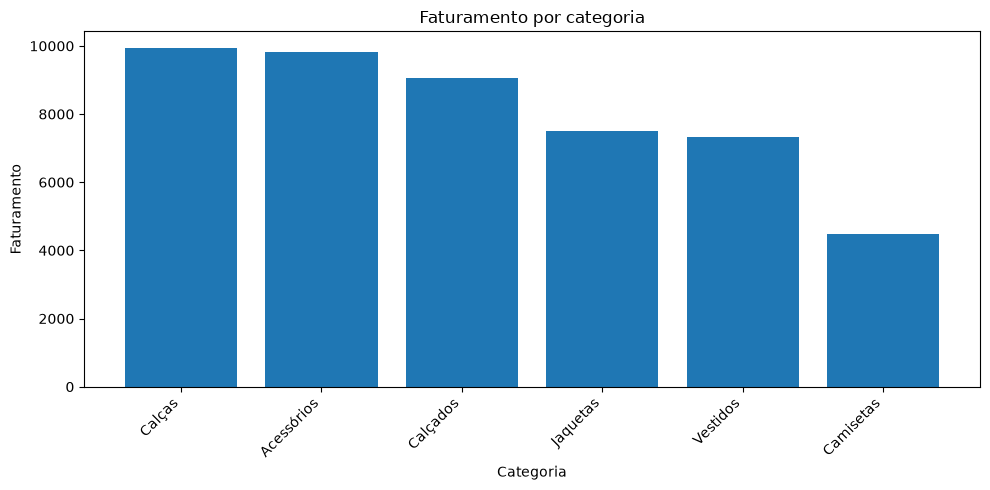

In [ ]:

plt.figure(figsize=(10, 5))
plt.bar(vendas_categoria["categoria"], vendas_categoria["valor_item"])
plt.title("Faturamento por categoria")
plt.xlabel("Categoria")
plt.ylabel("Faturamento")
plt.xticks(rotation=45, ha="right") # Rotaciona os rótulos do eixo X e alinha à direita
plt.tight_layout() # Ajusta o layout para evitar sobreposição de elementos
plt.show()



**Interpretação:**

A categoria com maior faturamento pode receber atenção especial em estoque, campanhas comerciais e planejamento de vendas.



## 6. Pergunta de negócio 2
### Quais estados apresentam maior faturamento?

Essa visão permite comparar o desempenho comercial por estado.


In [8]:

vendas_estado = (
    df_vendas
    .groupby("estado", as_index=False)["valor_item"]
    .sum()
    .sort_values("valor_item", ascending=False)
)

vendas_estado


,estado,valor_item
0,SC,48124.44


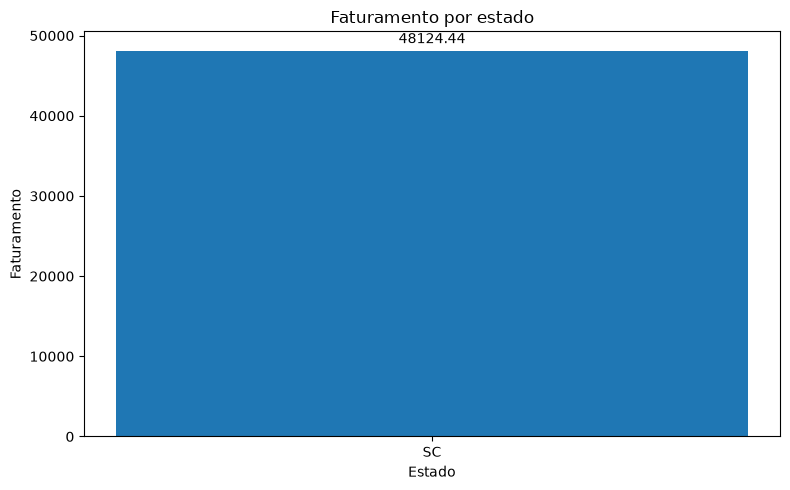

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

barras = ax.bar(
    vendas_estado["estado"],
    vendas_estado["valor_item"]
)

ax.set_title("Faturamento por estado")
ax.set_xlabel("Estado")
ax.set_ylabel("Faturamento")

# Exibir os valores sobre as barras
ax.bar_label(
    barras,
    fmt="%.2f",
    padding=3
)

plt.tight_layout()
plt.show()



## 7. Pergunta de negócio 3
### Quais produtos possuem maior faturamento?

Essa análise ajuda a identificar produtos com maior contribuição financeira.


In [10]:

vendas_produto = (
    df_vendas
    .groupby("produto", as_index=False)["valor_item"]
    .sum()
    .sort_values("valor_item", ascending=False)
)

vendas_produto.head(10)


,produto,valor_item
11,Jaqueta Corta-Vento,5597.76
0,Bolsa Transversal,4825.16
14,Tênis Casual Branco,4817.62
16,Vestido Curto Casual,4572.48
15,Tênis Esportivo,4254.48
3,Calça Jeans Slim,3897.40
5,Calça Sarja Masculina,3091.82
4,Calça Mom Feminina,2942.16
17,Vestido Midi Floral,2763.06
8,Camiseta Polo Masculina,2697.00


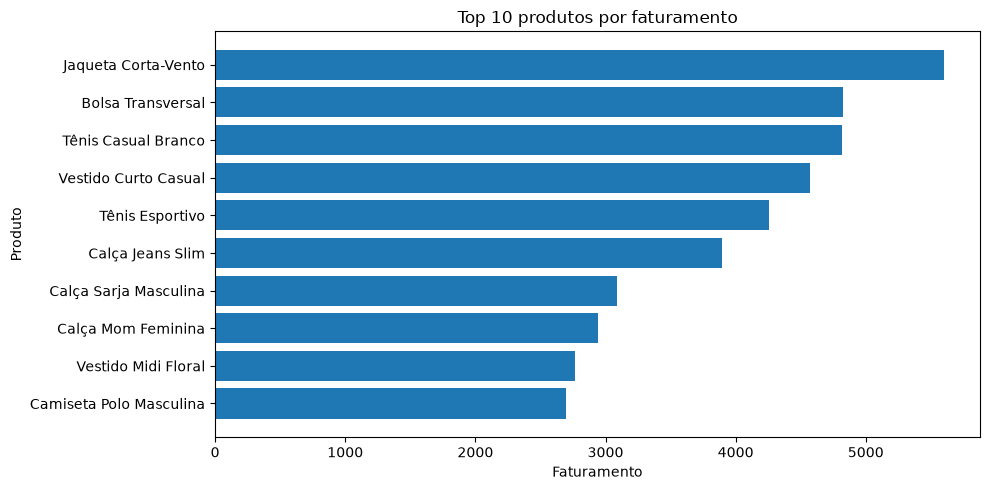

In [12]:

top_produtos = vendas_produto.head(10)

plt.figure(figsize=(10, 5))
plt.barh(top_produtos["produto"], top_produtos["valor_item"])
plt.title("Top 10 produtos por faturamento")
plt.xlabel("Faturamento")
plt.ylabel("Produto")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()



## 8. Pergunta de negócio 4
### As metas de vendas foram atingidas?

A tabela `gold.fato_metas_mensais` já possui os valores consolidados por ano, mês e estado.


In [15]:

display(df_metas_mensais.head())

colunas_meta = [
    "ano",
    "mes",
    "estado",
    "vendas_realizadas",
    "meta_vendas",
    "percentual_atingimento",
    "situacao_meta"
]

df_metas_mensais[colunas_meta]


,ano,mes,estado,meta_vendas,vendas_realizadas,percentual_atingimento,situacao_meta
0,2025,2,SC,5500,4727.98,85.96,Meta não atingida
1,2025,3,SC,6000,4768.07,79.47,Meta não atingida
2,2025,4,SC,6500,4573.46,70.36,Meta não atingida
3,2025,5,SC,7000,5419.51,77.42,Meta não atingida
4,2025,6,SC,7500,4837.02,64.49,Meta não atingida


,ano,mes,estado,vendas_realizadas,meta_vendas,percentual_atingimento,situacao_meta
0,2025,2,SC,4727.98,5500,85.96,Meta não atingida
1,2025,3,SC,4768.07,6000,79.47,Meta não atingida
2,2025,4,SC,4573.46,6500,70.36,Meta não atingida
3,2025,5,SC,5419.51,7000,77.42,Meta não atingida
4,2025,6,SC,4837.02,7500,64.49,Meta não atingida
5,2025,7,SC,6702.71,8000,83.78,Meta não atingida
6,2025,8,SC,6108.68,8500,71.87,Meta não atingida
7,2025,9,SC,1985.76,9000,22.06,Meta não atingida
8,2025,10,SC,4199.88,9500,44.21,Meta não atingida
9,2025,11,SC,2196.86,10500,20.92,Meta não atingida


In [16]:

quantidade_atingidas = (
    df_metas_mensais["situacao_meta"] == "Meta atingida"
).sum()

quantidade_total = len(df_metas_mensais)

percentual_atingidas = (
    quantidade_atingidas / quantidade_total * 100
    if quantidade_total > 0 else 0
)

print(f"Metas atingidas: {quantidade_atingidas}")
print(f"Total de combinações analisadas: {quantidade_total}")
print(f"Percentual de metas atingidas: {percentual_atingidas:.2f}%")


Metas atingidas: 0
Total de combinações analisadas: 11
Percentual de metas atingidas: 0.00%


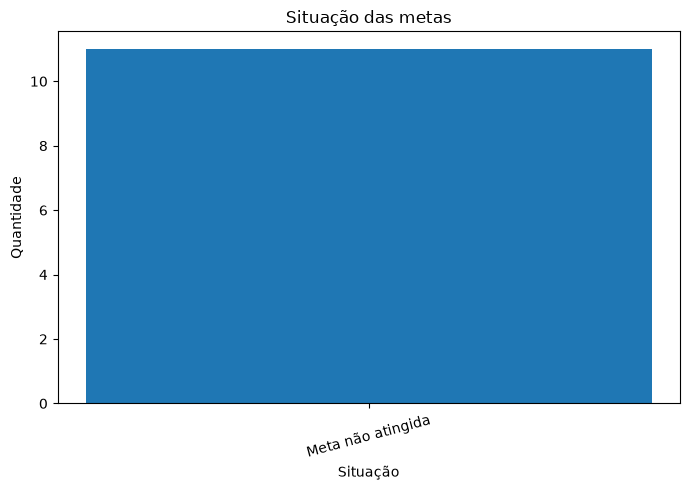

In [17]:

situacao_meta = (
    df_metas_mensais["situacao_meta"]
    .value_counts()
)

plt.figure(figsize=(7, 5))
plt.bar(situacao_meta.index, situacao_meta.values)
plt.title("Situação das metas")
plt.xlabel("Situação")
plt.ylabel("Quantidade")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()



## 9. Pergunta de negócio 5
### Quais estados mais se aproximam ou ultrapassam a meta?

Vamos calcular o percentual médio de atingimento por estado.


In [18]:

atingimento_estado = (
    df_metas_mensais
    .groupby("estado", as_index=False)["percentual_atingimento"]
    .mean()
    .sort_values("percentual_atingimento", ascending=False)
)

atingimento_estado


,estado,percentual_atingimento
0,SC,58.385455


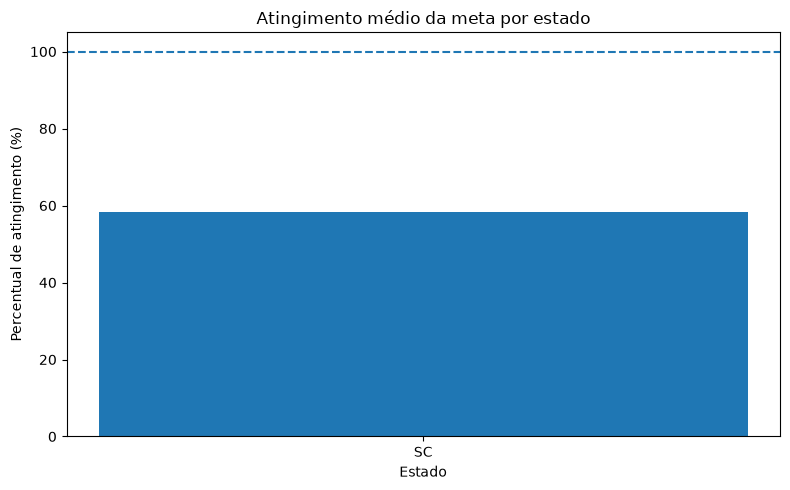

In [19]:

plt.figure(figsize=(8, 5))
plt.bar(
    atingimento_estado["estado"],
    atingimento_estado["percentual_atingimento"]
)
plt.axhline(100, linestyle="--")
plt.title("Atingimento médio da meta por estado")
plt.xlabel("Estado")
plt.ylabel("Percentual de atingimento (%)")
plt.tight_layout()
plt.show()



## 10. Pergunta de negócio 6
### Qual é o valor médio das vendas por categoria?

O valor médio pode ajudar a identificar categorias com itens de maior valor financeiro.


In [20]:

media_categoria = (
    df_vendas
    .groupby("categoria", as_index=False)["valor_item"]
    .mean()
    .rename(columns={"valor_item": "valor_medio"})
    .sort_values("valor_medio", ascending=False)
)

media_categoria


,categoria,valor_medio
4,Jaquetas,577.761538
1,Calçados,477.478947
2,Calças,381.976154
5,Vestidos,349.311429
0,Acessórios,196.136200
3,Camisetas,186.154583



## 11. Exemplo de consulta com filtro

Podemos filtrar a Gold para analisar somente uma categoria, estado ou período.


In [21]:

# Exemplo: vendas acima de 500 reais por item
df_vendas[df_vendas["valor_item"] > 500].head(10)


,id_pedido,data_pedido,id_cliente,cliente,cidade,estado,id_ibge,id_produto,produto,categoria,marca,quantidade,preco_unitario,desconto,valor_item
3,2,2025-02-19,15,Otávio Ribeiro,Chapecó,SC,4204202,11,Tênis Casual Branco,Calçados,Urban,3,199.9,5.0,569.72
11,5,2025-03-18,16,Patrícia Mendes,Blumenau,SC,4202404,4,Calça Jeans Slim,Calças,Viva Moda,4,149.9,10.0,539.64
19,8,2025-04-14,17,Rafael Gomes,Pomerode,SC,4213203,12,Tênis Esportivo,Calçados,Movimento,2,279.9,0.0,559.80
25,10,2025-05-02,11,Karina Souza,Gaspar,SC,4205902,4,Calça Jeans Slim,Calças,Viva Moda,4,149.9,10.0,539.64
29,13,2025-05-29,12,Lucas Pereira,Indaial,SC,4207502,12,Tênis Esportivo,Calçados,Movimento,2,279.9,0.0,559.80
33,14,2025-06-07,19,Thiago Nunes,Balneário Camboriú,SC,4202008,6,Calça Mom Feminina,Calças,Urban,4,159.9,10.0,575.64
36,15,2025-06-16,6,Felipe Almeida,Brusque,SC,4202909,4,Calça Jeans Slim,Calças,Viva Moda,4,149.9,10.0,539.64
43,17,2025-07-04,20,Vanessa Cardoso,Brusque,SC,4202909,10,Jaqueta Corta-Vento,Jaquetas,Movimento,4,249.9,10.0,899.64
45,19,2025-07-22,14,Natália Rocha,São José,SC,4216602,6,Calça Mom Feminina,Calças,Urban,4,159.9,10.0,575.64
50,20,2025-07-31,1,Ana Paula Martins,Florianópolis,SC,4205407,7,Vestido Midi Floral,Vestidos,Serra Sul,3,189.9,5.0,541.22



## 12. Conclusão

Neste notebook, utilizamos a camada Gold para:

- realizar estatística descritiva;
- analisar faturamento por categoria, produto e estado;
- acompanhar a evolução mensal;
- avaliar o atingimento das metas;
- criar gráficos para apoiar a interpretação;
- transformar dados em respostas de negócio.

### Fluxo aprendido

**ETL → Bronze → Silver → Gold → Análise → Decisão de negócio**

A Gold não é apenas o destino final do ETL. Ela organiza os dados para que analistas, gestores e ferramentas de BI consigam gerar informações úteis para o negócio.
